In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
results_df = pd.read_csv("../outputs/simulations/summary_with_mastro.csv", index_col=0)
results_old_df = pd.read_csv("../outputs/simulations/summary.csv", index_col=0)
results_old_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,our_ilp_no_max_alt_dependency_accuracy,MASTRO_trajectory_accuracy
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,0.0,<NOT_DONE>
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,0.0,<NOT_DONE>
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,0.0,<NOT_DONE>
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,0.0,<NOT_DONE>
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,0.0,<NOT_DONE>
...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.0,NaN
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,0.0,NaN
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN


In [7]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,...,MASTRO_expanded_dependency_recall,MASTRO_expanded_dependency_accuracy,PhyloPath_expanded_dependency_precision,PhyloPath_expanded_dependency_recall,PhyloPath_expanded_dependency_accuracy,our_ilp_max_2_alt_alteration_f1,our_ilp_no_max_alt_alteration_f1,MASTRO_alteration_f1,MASTRO_expanded_dependency_f1,PhyloPath_expanded_dependency_f1
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,...,0.50,0.50,0.6,1.000000,1.000000,0.909091,0.333333,1.000000,0.444444,0.750
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,...,0.25,0.25,1.0,1.000000,1.000000,1.000000,0.230769,0.888889,0.250000,1.000
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,...,0.75,0.75,0.5,0.833333,0.833333,0.727273,0.434783,0.833333,0.461538,0.625
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,...,0.75,0.75,1.0,1.000000,1.000000,1.000000,0.384615,0.625000,0.428571,1.000
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,...,0.50,0.50,0.5,0.833333,0.833333,0.727273,0.357143,0.666667,0.444444,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,0.909091,0.555556,0.200000,1.000
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,1.000000,0.400000,0.186047,1.000
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,...,1.00,1.00,0.6,1.000000,1.000000,0.909091,0.909091,0.454545,0.186047,0.750
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,0.909091,0.500000,0.205128,1.000


In [8]:
results_df["MASTRO_alteration_f1"] = results_df["MASTRO_alteration_f1"].fillna(0)
results_df["MASTRO_expanded_dependency_f1"] = results_df["MASTRO_expanded_dependency_f1"].fillna(0)

In [9]:
results_df = results_df[results_df['p2'] != 0.2]

In [10]:
print(np.median(results_df['our_ilp_max_2_alt_alteration_f1']))
print(np.median(results_df['PhyloPath_expanded_dependency_f1']))
print(np.median(results_df['MASTRO_alteration_f1']))
print(np.median(results_df['MASTRO_expanded_dependency_f1']))


1.0
1.0
0.6666666666666666
0.3478260869565217


In [18]:
from boxplot import plot_method_boxplot

In [19]:
alteration_precision_cols = [
    'our_ilp_max_2_alt_alteration_precision',
    'MASTRO_alteration_precision'
]

alteration_recall_cols = [
    'our_ilp_max_2_alt_alteration_recall',
    'MASTRO_alteration_recall'

]

alteration_f1_cols = [
    'our_ilp_max_2_alt_alteration_f1',
    'MASTRO_alteration_f1'
]


pathway_accuracy_cols = [
    'our_ilp_max_2_alt_pathway_accuracy',
]

dependency_accuracy_cols = [
    'our_ilp_max_2_alt_dependency_accuracy'
]

mastro_trajectory_accuracy_cols = [
    'MASTRO_trajectory_accuracy'
]

expanded_dependancy_accuracy_cols = [
    'PhyloPath_expanded_dependency_accuracy',
    'MASTRO_expanded_dependency_accuracy',
]

expanded_dependancy_precision_cols = [
    'PhyloPath_expanded_dependency_precision',
    'MASTRO_expanded_dependency_precision',
]

expanded_dependancy_recall_cols = [
    'PhyloPath_expanded_dependency_recall',
    'MASTRO_expanded_dependency_recall',
]

expanded_dependancy_f1_cols = [
    'PhyloPath_expanded_dependency_f1',
    'MASTRO_expanded_dependency_f1',
]

In [20]:
palette = {
    'PhyloStage': 'seagreen',
    'MASTRO': 'maroon',
}

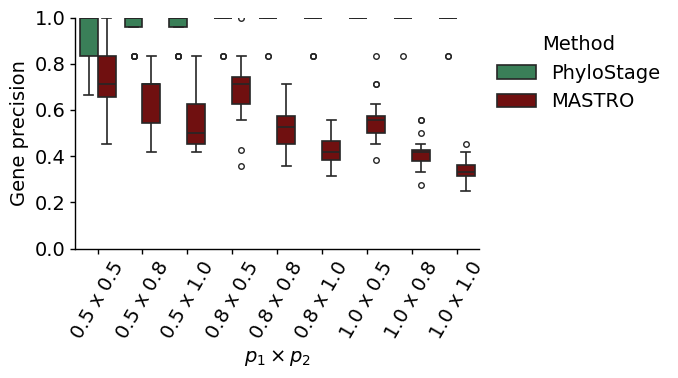

In [23]:
plot_method_boxplot(
    results_df,
    value_cols=alteration_precision_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'our_ilp_max_2_alt_alteration_precision': 'PhyloStage',
        'MASTRO_alteration_precision': 'MASTRO',
    },
    ylabel="Gene precision",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/alteration_precision_boxplot.svg"
)

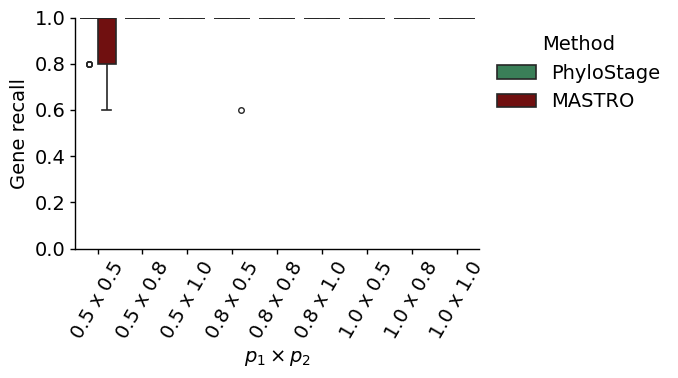

In [24]:
plot_method_boxplot(
    results_df,
    value_cols=alteration_recall_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'our_ilp_max_2_alt_alteration_recall': 'PhyloStage',
        'MASTRO_alteration_recall': 'MASTRO',
    },
    ylabel="Gene recall",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/alteration_recall_boxplot.svg"
)

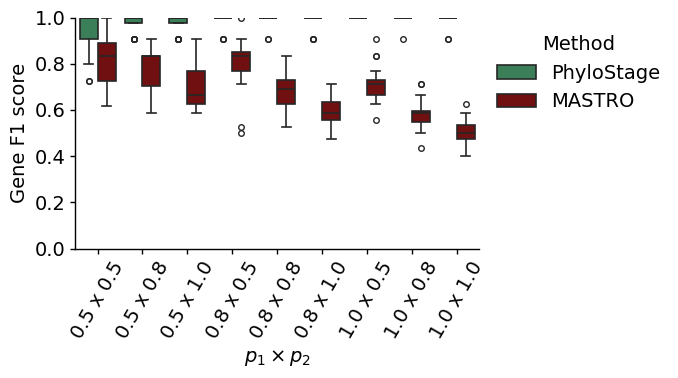

In [25]:
plot_method_boxplot(
    results_df,
    value_cols=alteration_f1_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'our_ilp_max_2_alt_alteration_f1': 'PhyloStage',
        'MASTRO_alteration_f1': 'MASTRO',
    },
    ylabel="Gene F1 score",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/alteration_f1_boxplot.svg"
)

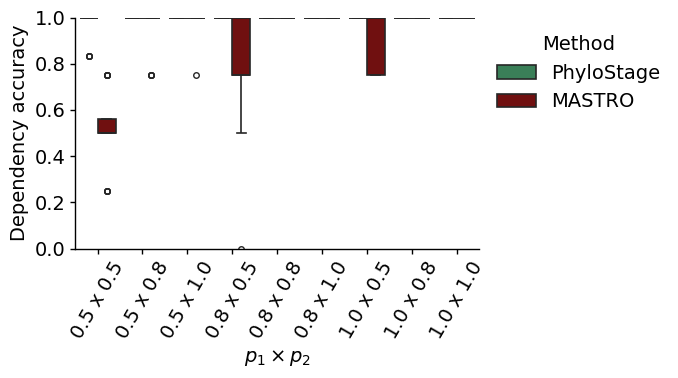

In [27]:
plot_method_boxplot(
    results_df,
    value_cols=expanded_dependancy_accuracy_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'PhyloPath_expanded_dependency_accuracy': 'PhyloStage',
        'MASTRO_expanded_dependency_accuracy': 'MASTRO',
    
    },
    ylabel="Dependency accuracy",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/expanded_dependency_accuracy_boxplot.svg"
)

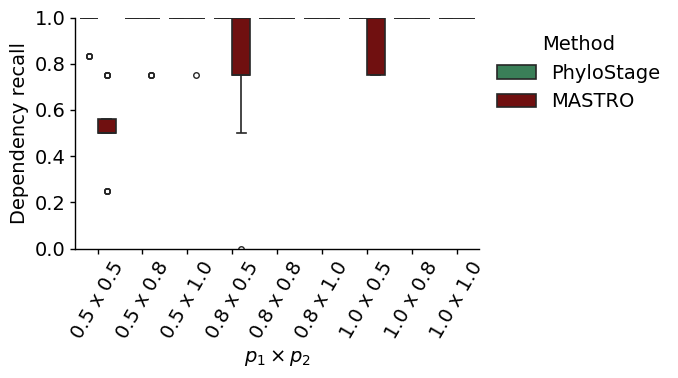

In [28]:
plot_method_boxplot(
    results_df,
    value_cols=expanded_dependancy_recall_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'MASTRO_expanded_dependency_recall': 'MASTRO',
        'PhyloPath_expanded_dependency_recall': 'PhyloStage',
    },
    ylabel="Dependency recall",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/expanded_dependency_recall_boxplot.svg"
)

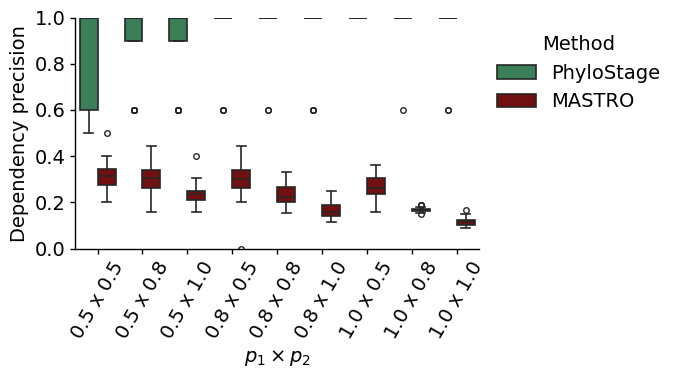

In [29]:
plot_method_boxplot(
    results_df,
    value_cols=expanded_dependancy_precision_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'MASTRO_expanded_dependency_precision': 'MASTRO',
        'PhyloPath_expanded_dependency_precision': 'PhyloStage',
    },
    ylabel="Dependency precision",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/expanded_dependency_precision_boxplot.svg"
)

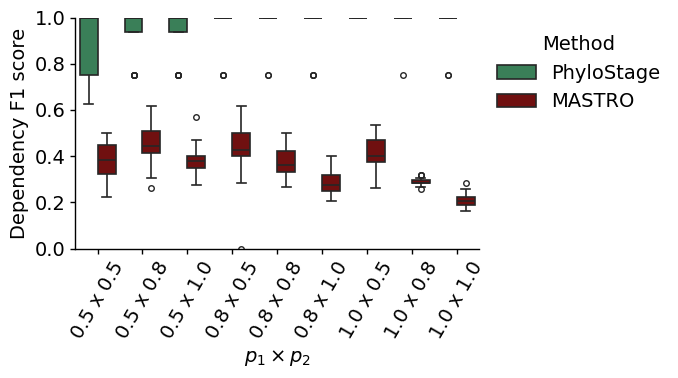

In [30]:
plot_method_boxplot(
    results_df,
    value_cols=expanded_dependancy_f1_cols,
    id_vars=['p1', 'p2'],
    method_name_map={
        'PhyloPath_expanded_dependency_f1': 'PhyloStage',
        'MASTRO_expanded_dependency_f1': 'MASTRO',
    
    },
    ylabel="Dependency F1 score",
    xlabel="$p_1 \\times p_2$",
    palette=palette,
    ylim=(0, 1),
    output_path="../outputs/figures/simulation/expanded_dependency_f1_boxplot.svg"
)

## Runtimes

In [31]:
import re

def parse_runtimes(path):
    """
    Parse runtimes from the log file.

    Returns
    -------
    dict with keys:
        ilp_max_runtime
        ilp_no_max_runtime
        mastro_runtime
    """
    
    runtimes = {
        "ilp_max_runtime": None,
        "ilp_no_max_runtime": None,
        "mastro_runtime": None
    }

    ilp_times = []

    with open(path, "r") as f:
        text = f.read()

    # ILP runtimes
    ilp_matches = re.findall(
        r"Running all of problem_1_1\(\) took ([0-9.eE+-]+) seconds", 
        text
    )
    ilp_times = [float(x) for x in ilp_matches]

    if len(ilp_times) >= 1:
        runtimes["ilp_max_runtime"] = ilp_times[0]
    if len(ilp_times) >= 2:
        runtimes["ilp_no_max_runtime"] = ilp_times[1]

    # MASTRO runtime
    mastro_match = re.search(
        r"time took to run run_MASTRO function:\s*([0-9.eE+-]+)", 
        text
    )
    if mastro_match:
        runtimes["mastro_runtime"] = float(mastro_match.group(1))

    return runtimes

In [32]:
import re
from pathlib import Path
import pandas as pd


def parse_runtimes(path):
    runtimes = {
        "ilp_max_runtime": None,
        "ilp_no_max_runtime": None,
        "mastro_runtime": None
    }

    with open(path, "r") as f:
        text = f.read()

    # ILP runtimes
    ilp_matches = re.findall(
        r"Running all of problem_1_1\(\) took ([0-9.eE+-]+) seconds",
        text
    )
    ilp_times = [float(x) for x in ilp_matches]

    if len(ilp_times) >= 1:
        runtimes["ilp_max_runtime"] = ilp_times[0]
    if len(ilp_times) >= 2:
        runtimes["ilp_no_max_runtime"] = ilp_times[1]

    # MASTRO runtime
    m = re.search(
        r"time took to run run_MASTRO function:\s*([0-9.eE+-]+)",
        text
    )
    if m:
        runtimes["mastro_runtime"] = float(m.group(1))

    return runtimes


def parse_all_logs(base_dir="../outputs/simulations"):
    rows = []

    base = Path(base_dir)

    for log_path in base.glob("*_*/*/log.txt"):
        # path structure: p1_p2/seed/log.txt
        p1_p2 = log_path.parent.parent.name
        seed = int(log_path.parent.name)

        p1, p2 = map(float, p1_p2.split("_"))

        runtimes = parse_runtimes(log_path)

        rows.append({
            "p1": p1,
            "p2": p2,
            "seed": seed,
            **runtimes
        })

    df = pd.DataFrame(rows)

    return df.sort_values(["p1", "p2", "seed"]).reset_index(drop=True)

In [34]:
df = parse_all_logs("../outputs/simulations")
df = df[df['p2'] != 0.2]
df

,p1,p2,seed,ilp_max_runtime,ilp_no_max_runtime,mastro_runtime
0,0.5,0.5,1,7.360016,259.376984,1.216625
1,0.5,0.5,2,7.277005,729.172541,1.275230
2,0.5,0.5,3,5.026804,186.752831,1.273678
3,0.5,0.5,4,5.271146,169.460131,1.301762
4,0.5,0.5,5,9.681052,1583.126065,1.182765
...,...,...,...,...,...,...
186,1.0,1.0,16,0.129070,0.329652,0.811165
187,1.0,1.0,17,0.112661,0.131265,0.782412
188,1.0,1.0,18,0.143644,0.338722,0.836878
189,1.0,1.0,19,0.126982,0.273860,0.826482


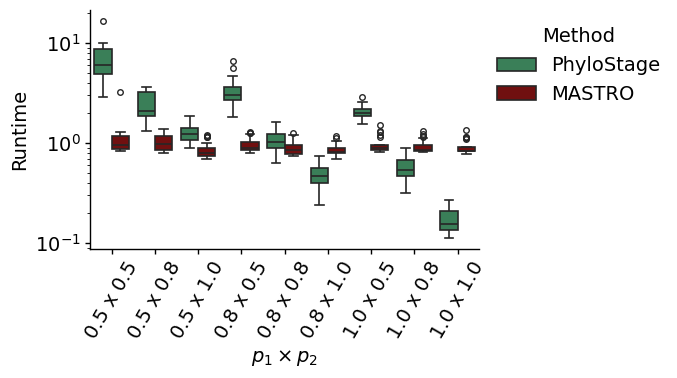

In [35]:
plot_method_boxplot(
    df,
    value_cols=[
        'ilp_max_runtime', 
        # 'ilp_no_max_runtime', 
        'mastro_runtime'
    ],
    id_vars=['p1', 'p2'],
    method_name_map={
        'ilp_max_runtime': 'PhyloStage',
        # 'ilp_no_max_runtime': 'PhyloPath (no limit)',
        'mastro_runtime': 'MASTRO',
    },
    palette={
        'PhyloStage': 'seagreen',
        # 'PhyloPath (no limit)': 'lightblue',
        'MASTRO': 'maroon',
    },
    ylabel="Runtime",
    xlabel="$p_1 \\times p_2$",
    ylim=None,
    yscale="log",
    figsize=(7, 4),
    output_path='../outputs/figures/simulation/runtime.pdf',
)

## Calculate MASTRO metrics

### Alteration Accuracy

In [326]:
pathways = [['IDH1', 'IDH2'], ['SRSF2'], ['NRAS', 'KRAS']]

true_alterations = set(alteration for pathway in pathways for alteration in pathway)

print(true_alterations)

{'NRAS', 'IDH1', 'IDH2', 'KRAS', 'SRSF2'}


In [ ]:
p1 = 0.5
p2 = 0.5
seed = 1

mastro_df = pd.read_csv(f"../outputs/simulations/{p1}_{p2}/{seed}/MASTRO_results.csv", index_col=0)

mastro_df

,edges_traj,traj_occ_list,traj_alt_occ_list,traj_supp,traj_freq,traj_exp_ind,traj_var_ind,t_stat_ind,t_stat_norm_ind,pval_ind,traj_exp_perm,traj_var_perm,t_stat_perm,t_stat_norm_perm,pval_perm,traj_exp_topol,traj_var_topol,t_stat_topol,t_stat_norm_topol,pval_topol
0,[IDH1->-SRSF2],"[0, 1, 26, 34, 39, 48, 49, 51, 60, 62, 70, 79,...","[0, 1, 26, 34, 39, 48, 49, 51, 60, 62, 70, 79,...",16,0.133333,0.050029,0.000273,0.083305,5.037570,0.000001,0.067599,0.000301,0.065734,3.789484,0.000116,NaN,NaN,NaN,NaN,NaN
1,[IDH2->-SRSF2],"[6, 9, 11, 18, 20, 23, 32, 45, 52, 84, 111, 117]","[6, 9, 11, 18, 20, 23, 32, 45, 52, 84, 111, 117]",12,0.100000,0.033544,0.000182,0.066456,4.923256,0.000001,0.045754,0.000200,0.054246,3.832350,0.000060,NaN,NaN,NaN,NaN,NaN
2,[IDH1-/-IDH2],"[43, 56, 61, 69, 82, 107, 111, 112]","[43, 56, 61, 69, 82, 107, 111, 112]",8,0.066667,0.020833,0.000104,0.045833,4.492465,0.000021,0.034444,0.000074,0.032222,3.755639,0.000549,NaN,NaN,NaN,NaN,NaN
3,[IDH1->-NRAS],"[48, 51, 62, 70, 97]","[48, 51, 62, 70, 97]",5,0.041667,0.015214,0.000080,0.026453,2.950144,0.006457,0.020238,0.000086,0.021429,2.304664,0.026786,NaN,NaN,NaN,NaN,NaN
4,[SRSF2->-NRAS IDH1->-NRAS IDH1->-SRSF2],"[48, 51, 62, 70]","[48, 51, 62, 70]",4,0.033333,0.001885,0.000015,0.031449,8.179285,0.000009,0.005040,0.000035,0.028294,4.752172,0.000485,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,[FLT3->-IDH1],"[102, 110]","[21, 22, 102, 110, 114]",2,0.016667,0.013127,0.000073,0.003540,0.414717,0.504581,0.016270,0.000080,0.000397,0.044352,0.650446,NaN,NaN,NaN,NaN,NaN
102,[SRSF2->-MYC],"[11, 79]","[6, 11, 45, 79]",2,0.016667,0.012014,0.000064,0.004653,0.582477,0.455556,0.016667,0.000069,0.000000,0.000000,0.687500,NaN,NaN,NaN,NaN,NaN
103,[JAK2->-PPM1D],"[9, 75]","[9, 75]",2,0.016667,0.005382,0.000030,0.011285,2.048324,0.104167,0.007143,0.000033,0.009524,1.650274,0.178571,NaN,NaN,NaN,NaN,NaN
104,[EZH2->-FLT3],"[22, 110]","[22, 110]",2,0.016667,0.005565,0.000030,0.011102,2.010718,0.108571,0.006687,0.000033,0.009980,1.737263,0.158333,NaN,NaN,NaN,NaN,NaN


In [328]:
edge_trajectories = list(mastro_df["edges_traj"])

gene_set = set()
T_edges = [traj[1:-1].split(" ") for traj in edge_trajectories]

num_genes = []

for traj in edge_trajectories:
    T_edges = traj[1:-1].split(" ")
    gene_set = set()
    for edge in T_edges:
        if "->-" in edge:
            a,b = edge.split("->-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-/-" in edge:
            a,b = edge.split("-/-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-?-" in edge:
            a,b = edge.split("-?-")
            gene_set.add(a)
            gene_set.add(b)
    
    num_genes.append(len(gene_set))

mastro_df["num_genes"] = num_genes


In [329]:
def canonical_mastro_string(edges):
    norm = []

    for e in edges:
        if "->-" in e:
            a,b = e.split("->-")
            norm.append(f"{a}->-{b}")

        elif "-/-" in e:
            a,b = e.split("-/-")
            a,b = sorted([a,b])
            norm.append(f"{a}-/-{b}")

        elif "-?-" in e:
            a,b = e.split("-?-")
            a,b = sorted([a,b])
            norm.append(f"{a}-?-{b}")

    return " ".join(sorted(norm))

In [330]:
p_threshold = 0.01

In [331]:
# df_filtered_trajectories = mastro_df[mastro_df["num_genes"] == 3]
# trajectories = list(df_filtered_trajectories.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
# trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in trajectories]
# trajectories

df_filtered_trajectories = mastro_df
df_filtered_trajectories = df_filtered_trajectories[df_filtered_trajectories["pval_perm"] < p_threshold]
top_trajectories = list(df_filtered_trajectories['edges_traj'])
top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]
top_trajectories


['IDH1->-SRSF2',
 'IDH2->-SRSF2',
 'IDH1-/-IDH2',
 'IDH1->-NRAS IDH1->-SRSF2 SRSF2->-NRAS',
 'IDH2->-KRAS IDH2->-SRSF2 SRSF2->-KRAS']

In [332]:
predicted_alterations = set()

for traj in top_trajectories:

    for e in traj.split(' '):
        a = None
        b = None
        if "->-" in e:
            a,b = e.split("->-")

        elif "-/-" in e:
            a,b = e.split("-/-")
            
        elif "-?-" in e:
            a,b = e.split("-?-")
        
        predicted_alterations.add(a)
        predicted_alterations.add(b)

print(predicted_alterations)

{'NRAS', 'IDH1', 'IDH2', 'KRAS', 'SRSF2'}


In [333]:
alteration_recall = len(true_alterations & predicted_alterations) / len(true_alterations)
alteration_precision = len(true_alterations & predicted_alterations) / len(predicted_alterations)

print(alteration_precision, alteration_recall)
    

1.0 1.0


In [334]:
def clean_val(x):
    """Convert float to string for folder names: integers lose .0, fractions keep decimal."""
    x = float(x)
    return str(int(x)) if x.is_integer() else str(x)

In [ ]:
def get_alteration_accuracy(p1, p2, seed):

    p1_str = clean_val(p1)
    p2_str = clean_val(p2)
    seed = clean_val(seed)
    
    mastro_df = pd.read_csv(f"../outputs/simulations/{p1_str}_{p2_str}/{seed}/MASTRO_results.csv")

    edge_trajectories = list(mastro_df["edges_traj"])

    gene_set = set()
    edges = [traj[1:-1].split(" ") for traj in edge_trajectories]

    num_genes = []

    for traj in edge_trajectories:
        edges = traj[1:-1].split(" ")
        gene_set = set()
        for edge in edges:
            if "->-" in edge:
                a,b = edge.split("->-")
                gene_set.add(a)
                gene_set.add(b)

            elif "-/-" in edge:
                a,b = edge.split("-/-")
                gene_set.add(a)
                gene_set.add(b)

            elif "-?-" in edge:
                a,b = edge.split("-?-")
                gene_set.add(a)
                gene_set.add(b)
        
        num_genes.append(len(gene_set))

    mastro_df["num_genes"] = num_genes

    # df_filtered_trajectories = mastro_df[mastro_df["num_genes"] == 3]
    # trajectories = list(df_filtered_trajectories.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
    # trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in trajectories]

    df_filtered_trajectories = mastro_df
    df_filtered_trajectories = df_filtered_trajectories[df_filtered_trajectories["pval_perm"] < p_threshold]
    trajectories = list(df_filtered_trajectories['edges_traj'])
    trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in trajectories]
    
    predicted_alterations = set()

    for traj in trajectories:

        for e in traj.split(' '):
            a = None
            b = None
            if "->-" in e:
                a,b = e.split("->-")

            elif "-/-" in e:
                a,b = e.split("-/-")
                
            elif "-?-" in e:
                a,b = e.split("-?-")
            
            predicted_alterations.add(a)
            predicted_alterations.add(b)
    
    tp = len(true_alterations & predicted_alterations)
    n_true = len(true_alterations)
    n_pred = len(predicted_alterations)

    recall = tp / n_true if n_true else 0.0
    precision = tp / n_pred if n_pred else 0.0
    
    return pd.Series({
        "MASTRO_alteration_precision": precision,
        "MASTRO_alteration_recall": recall,
    })

In [336]:
metrics_df = results_df.apply(
    lambda r: get_alteration_accuracy(r.p1, r.p2, r.seed),
    axis=1
)

# Concatenate new columns with original dataframe
results_df = pd.concat([results_old_df, metrics_df], axis=1)

In [337]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,our_ilp_no_max_alt_dependency_accuracy,MASTRO_trajectory_accuracy,MASTRO_alteration_precision,MASTRO_alteration_recall
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,0.0,<NOT_DONE>,1.000000,1.0
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,0.0,<NOT_DONE>,1.000000,0.8
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,0.0,<NOT_DONE>,0.714286,1.0
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,0.0,<NOT_DONE>,0.454545,1.0
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,0.0,<NOT_DONE>,0.571429,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.384615,1.0
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.0,NaN,0.250000,1.0
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,0.0,NaN,0.294118,1.0
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.333333,1.0


In [ ]:
results_df.to_csv("../outputs/simulations/summary_with_mastro.csv")

### Trajectory Accuracy

In [339]:
pathways = [['IDH1', 'IDH2'], ['SRSF2'], ['NRAS', 'KRAS']]

In [ ]:
p1 = 1
p2 = 1
seed = 1

mastro_df = pd.read_csv(f"../outputs/simulations/{p1}_{p2}/{seed}/MASTRO_results.csv", index_col=0)

mastro_df

,edges_traj,traj_occ_list,traj_alt_occ_list,traj_supp,traj_freq,traj_exp_ind,traj_var_ind,t_stat_ind,t_stat_norm_ind,pval_ind,traj_exp_perm,traj_var_perm,t_stat_perm,t_stat_norm_perm,pval_perm,traj_exp_topol,traj_var_topol,t_stat_topol,t_stat_norm_topol,pval_topol
0,[IDH2->-SRSF2],"[2, 3, 6, 8, 10, 12, 14, 16, 17, 18, 23, 25, 2...","[2, 3, 6, 8, 10, 12, 14, 16, 17, 18, 21, 22, 2...",59,0.491667,0.149539,0.000871,0.342128,11.591477,1.384823e-27,0.222004,0.001024,0.269663,8.426488,5.085085e-18,NaN,NaN,NaN,NaN,NaN
1,[IDH1->-SRSF2],"[0, 1, 7, 9, 11, 13, 15, 19, 20, 21, 24, 26, 2...","[0, 1, 7, 9, 11, 13, 15, 19, 20, 21, 24, 26, 2...",52,0.433333,0.137633,0.000785,0.295701,10.553390,1.103923e-23,0.198234,0.000909,0.235099,7.797547,9.351992e-16,NaN,NaN,NaN,NaN,NaN
2,[SRSF2->-KRAS],"[1, 3, 7, 9, 11, 12, 13, 15, 16, 17, 19, 20, 2...","[1, 3, 7, 9, 11, 12, 13, 15, 16, 17, 19, 20, 2...",49,0.408333,0.138383,0.000757,0.269951,9.810863,6.428720e-24,0.189623,0.000834,0.218710,7.571704,2.929755e-17,NaN,NaN,NaN,NaN,NaN
3,[SRSF2->-NRAS],"[0, 6, 9, 21, 23, 32, 39, 45, 47, 48, 50, 53, ...","[0, 6, 9, 21, 22, 23, 32, 39, 45, 47, 48, 50, ...",31,0.258333,0.091641,0.000504,0.166692,7.422337,2.908839e-13,0.122976,0.000556,0.135357,5.742664,1.740664e-09,NaN,NaN,NaN,NaN,NaN
4,[IDH1->-KRAS SRSF2->-KRAS IDH1->-SRSF2],"[1, 7, 9, 11, 13, 15, 19, 20, 26, 42, 47, 51, ...","[1, 7, 9, 11, 13, 15, 19, 20, 26, 34, 42, 47, ...",25,0.208333,0.010493,0.000083,0.197840,21.769119,5.182699e-33,0.028542,0.000203,0.179792,12.616403,4.026325e-22,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,[IDH2->-DNMT3A],"[22, 30]","[22, 30]",2,0.016667,0.004417,0.000027,0.012250,2.356605,7.000000e-02,0.005694,0.000031,0.010972,1.963377,1.166667e-01,NaN,NaN,NaN,NaN,NaN
77,[NRAS->-BCOR],"[22, 32]","[22, 32]",2,0.016667,0.005458,0.000030,0.011208,2.037002,1.050000e-01,0.007083,0.000033,0.009583,1.664222,1.750000e-01,NaN,NaN,NaN,NaN,NaN
78,[KIT-/-SRSF2 IDH2->-KIT IDH2->-SRSF2],"[94, 105]","[48, 94, 105]",2,0.016667,0.001417,0.000011,0.015249,4.642462,7.111111e-03,0.004444,0.000027,0.012222,2.372321,6.666667e-02,NaN,NaN,NaN,NaN,NaN
79,[IDH2->-TET2],"[52, 111]","[52, 111]",2,0.016667,0.004343,0.000025,0.012324,2.447506,5.777778e-02,0.005278,0.000028,0.011389,2.146038,8.666667e-02,NaN,NaN,NaN,NaN,NaN


In [341]:
edge_trajectories = list(mastro_df["edges_traj"])

gene_set = set()
T_edges = [traj[1:-1].split(" ") for traj in edge_trajectories]

num_genes = []

for traj in edge_trajectories:
    T_edges = traj[1:-1].split(" ")
    gene_set = set()
    for edge in T_edges:
        if "->-" in edge:
            a,b = edge.split("->-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-/-" in edge:
            a,b = edge.split("-/-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-?-" in edge:
            a,b = edge.split("-?-")
            gene_set.add(a)
            gene_set.add(b)
    
    num_genes.append(len(gene_set))

mastro_df["num_genes"] = num_genes


In [342]:
def canonical_mastro_string(edges):
    norm = []

    for e in edges:
        if "->-" in e:
            a,b = e.split("->-")
            norm.append(f"{a}->-{b}")

        elif "-/-" in e:
            a,b = e.split("-/-")
            a,b = sorted([a,b])
            norm.append(f"{a}-/-{b}")

        elif "-?-" in e:
            a,b = e.split("-?-")
            a,b = sorted([a,b])
            norm.append(f"{a}-?-{b}")

    return " ".join(sorted(norm))

In [343]:
df_filtered_trajectories = mastro_df[mastro_df["num_genes"] == 3]
top_trajectories = list(df_filtered_trajectories.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]
top_trajectories

['IDH1->-KRAS IDH1->-SRSF2 SRSF2->-KRAS',
 'IDH2->-KRAS IDH2->-SRSF2 SRSF2->-KRAS',
 'IDH1->-NRAS IDH1->-SRSF2 SRSF2->-NRAS',
 'IDH2->-NRAS IDH2->-SRSF2 SRSF2->-NRAS']

In [344]:
def canonical_mastro_string(edges):
    norm = []

    for e in edges:
        if "->-" in e:
            a,b = e.split("->-")
            norm.append(f"{a}->-{b}")

        elif "-/-" in e:
            a,b = e.split("-/-")
            a,b = sorted([a,b])
            norm.append(f"{a}-/-{b}")

        elif "-?-" in e:
            a,b = e.split("-?-")
            a,b = sorted([a,b])
            norm.append(f"{a}-?-{b}")

    return " ".join(sorted(norm))

In [345]:
true_trajectories = [
    'IDH1->-SRSF2 SRSF2->-NRAS IDH1->-NRAS',
    'IDH1->-SRSF2 SRSF2->-KRAS IDH1->-KRAS',
    'IDH2->-SRSF2 SRSF2->-NRAS IDH2->-NRAS',
    'IDH2->-SRSF2 SRSF2->-KRAS IDH2->-KRAS',
]

true_trajectories = [canonical_mastro_string(traj.split(" ")) for traj in true_trajectories]
true_trajectories

['IDH1->-NRAS IDH1->-SRSF2 SRSF2->-NRAS',
 'IDH1->-KRAS IDH1->-SRSF2 SRSF2->-KRAS',
 'IDH2->-NRAS IDH2->-SRSF2 SRSF2->-NRAS',
 'IDH2->-KRAS IDH2->-SRSF2 SRSF2->-KRAS']

In [ ]:
edge_trajectories = list(mastro_df["edges_traj"])

gene_set = set()
T_edges = [traj[1:-1].split(" ") for traj in edge_trajectories]

num_genes = []

for traj in edge_trajectories:
    T_edges = traj[1:-1].split(" ")
    gene_set = set()
    for edge in T_edges:
        if "->-" in edge:
            a,b = edge.split("->-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-/-" in edge:
            a,b = edge.split("-/-")
            gene_set.add(a)
            gene_set.add(b)

        elif "-?-" in edge:
            a,b = edge.split("-?-")
            gene_set.add(a)
            gene_set.add(b)
    
    num_genes.append(len(gene_set))

mastro_df["num_genes"] = num_genes


In [78]:
edge_trajectories = list(mastro_df["edges_traj"])
edge_trajectories_lens = [len(traj[1:-1].split(" ")) for traj in edge_trajectories]

mastro_df["length"] = edge_trajectories_lens


In [ ]:
df_filtered_trajectories = mastro_df[mastro_df["num_genes"] == 3]
top_trajectories = list(df_filtered_trajectories.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]
top_trajectories

['IDH1->-KRAS IDH1->-SRSF2 SRSF2->-KRAS',
 'IDH2->-KRAS IDH2->-SRSF2 SRSF2->-KRAS',
 'IDH1->-NRAS IDH1->-SRSF2 SRSF2->-NRAS',
 'IDH2->-NRAS IDH2->-SRSF2 SRSF2->-NRAS']

In [ ]:
accuracy = len(set(top_trajectories) & set(true_trajectories)) / len(true_trajectories)
accuracy

1.0

In [81]:
def clean_val(x):
    """Convert float to string for folder names: integers lose .0, fractions keep decimal."""
    x = float(x)
    return str(int(x)) if x.is_integer() else str(x)

In [ ]:
def get_trajectory_accuracy(p1, p2, seed):

    p1_str = clean_val(p1)
    p2_str = clean_val(p2)
    seed = clean_val(seed)
    
    mastro_df = pd.read_csv(f"../outputs/simulations/{p1_str}_{p2_str}/{seed}/MASTRO_results.csv")

    edge_trajectories = list(mastro_df["edges_traj"])
    edge_trajectories_lens = [len(traj[1:-1].split(" ")) for traj in edge_trajectories]

    mastro_df["length"] = edge_trajectories_lens

    edge_trajectories = list(mastro_df["edges_traj"])

    gene_set = set()
    edges = [traj[1:-1].split(" ") for traj in edge_trajectories]

    num_genes = []

    for traj in edge_trajectories:
        edges = traj[1:-1].split(" ")
        gene_set = set()
        for edge in edges:
            if "->-" in edge:
                a,b = edge.split("->-")
                gene_set.add(a)
                gene_set.add(b)

            elif "-/-" in edge:
                a,b = edge.split("-/-")
                gene_set.add(a)
                gene_set.add(b)

            elif "-?-" in edge:
                a,b = edge.split("-?-")
                gene_set.add(a)
                gene_set.add(b)
        
        num_genes.append(len(gene_set))

    mastro_df["num_genes"] = num_genes

    df_with_only_3_genes = mastro_df[mastro_df["num_genes"] == 3]
    df_top_trajectories = list(df_with_only_3_genes.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
    df_top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in df_top_trajectories]

    accuracy = len(set(df_top_trajectories) & set(true_trajectories)) / len(true_trajectories)

    return accuracy

In [93]:
results_df["MASTRO_trajectory_accuracy"] = results_df.apply(
    lambda r: get_trajectory_accuracy(r.p1, r.p2, r.seed),
    axis=1
)

In [94]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,our_ilp_no_max_alt_dependency_accuracy,MASTRO_trajectory_accuracy,MASTRO_alteration_precision,MASTRO_alteration_recall
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,0.0,0.50,1.0,0.625000
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,0.0,0.50,0.8,0.666667
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,0.0,0.75,1.0,0.833333
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,0.0,0.75,1.0,0.833333
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,0.0,0.00,0.6,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,1.00,1.0,1.000000
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.0,1.00,1.0,1.000000
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,0.0,1.00,1.0,1.000000
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,1.00,1.0,1.000000


In [ ]:
results_df.to_csv("../outputs/simulations/summary_2.csv")

### Expanded dependency metric

In [ ]:
p1 = 1
p2 = 1
seed = 1

mastro_df = pd.read_csv(f"../outputs/simulations/{p1}_{p2}/{seed}/MASTRO_results.csv", index_col=0)

mastro_df

,edges_traj,traj_occ_list,traj_alt_occ_list,traj_supp,traj_freq,traj_exp_ind,traj_var_ind,t_stat_ind,t_stat_norm_ind,pval_ind,traj_exp_perm,traj_var_perm,t_stat_perm,t_stat_norm_perm,pval_perm,traj_exp_topol,traj_var_topol,t_stat_topol,t_stat_norm_topol,pval_topol
0,[IDH2->-SRSF2],"[2, 3, 6, 8, 10, 12, 14, 16, 17, 18, 23, 25, 2...","[2, 3, 6, 8, 10, 12, 14, 16, 17, 18, 21, 22, 2...",59,0.491667,0.149539,0.000871,0.342128,11.591477,1.384823e-27,0.222004,0.001024,0.269663,8.426488,5.085085e-18,NaN,NaN,NaN,NaN,NaN
1,[IDH1->-SRSF2],"[0, 1, 7, 9, 11, 13, 15, 19, 20, 21, 24, 26, 2...","[0, 1, 7, 9, 11, 13, 15, 19, 20, 21, 24, 26, 2...",52,0.433333,0.137633,0.000785,0.295701,10.553390,1.103923e-23,0.198234,0.000909,0.235099,7.797547,9.351992e-16,NaN,NaN,NaN,NaN,NaN
2,[SRSF2->-KRAS],"[1, 3, 7, 9, 11, 12, 13, 15, 16, 17, 19, 20, 2...","[1, 3, 7, 9, 11, 12, 13, 15, 16, 17, 19, 20, 2...",49,0.408333,0.138383,0.000757,0.269951,9.810863,6.428720e-24,0.189623,0.000834,0.218710,7.571704,2.929755e-17,NaN,NaN,NaN,NaN,NaN
3,[SRSF2->-NRAS],"[0, 6, 9, 21, 23, 32, 39, 45, 47, 48, 50, 53, ...","[0, 6, 9, 21, 22, 23, 32, 39, 45, 47, 48, 50, ...",31,0.258333,0.091641,0.000504,0.166692,7.422337,2.908839e-13,0.122976,0.000556,0.135357,5.742664,1.740664e-09,NaN,NaN,NaN,NaN,NaN
4,[IDH1->-KRAS SRSF2->-KRAS IDH1->-SRSF2],"[1, 7, 9, 11, 13, 15, 19, 20, 26, 42, 47, 51, ...","[1, 7, 9, 11, 13, 15, 19, 20, 26, 34, 42, 47, ...",25,0.208333,0.010493,0.000083,0.197840,21.769119,5.182699e-33,0.028542,0.000203,0.179792,12.616403,4.026325e-22,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,[IDH2->-DNMT3A],"[22, 30]","[22, 30]",2,0.016667,0.004417,0.000027,0.012250,2.356605,7.000000e-02,0.005694,0.000031,0.010972,1.963377,1.166667e-01,NaN,NaN,NaN,NaN,NaN
77,[NRAS->-BCOR],"[22, 32]","[22, 32]",2,0.016667,0.005458,0.000030,0.011208,2.037002,1.050000e-01,0.007083,0.000033,0.009583,1.664222,1.750000e-01,NaN,NaN,NaN,NaN,NaN
78,[KIT-/-SRSF2 IDH2->-KIT IDH2->-SRSF2],"[94, 105]","[48, 94, 105]",2,0.016667,0.001417,0.000011,0.015249,4.642462,7.111111e-03,0.004444,0.000027,0.012222,2.372321,6.666667e-02,NaN,NaN,NaN,NaN,NaN
79,[IDH2->-TET2],"[52, 111]","[52, 111]",2,0.016667,0.004343,0.000025,0.012324,2.447506,5.777778e-02,0.005278,0.000028,0.011389,2.146038,8.666667e-02,NaN,NaN,NaN,NaN,NaN


In [347]:
import networkx as nx

In [348]:
edge_trajectories = list(mastro_df["edges_traj"])
edge_trajectories_lens = [len(traj[1:-1].split(" ")) for traj in edge_trajectories]

mastro_df["length"] = edge_trajectories_lens

# df_filtered_trajectories = mastro_df[mastro_df["length"] == 3]
# top_trajectories = list(df_filtered_trajectories.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
# top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]

df_filtered_trajectories = mastro_df
df_filtered_trajectories = df_filtered_trajectories[df_filtered_trajectories["pval_perm"] < p_threshold]
top_trajectories = list(df_filtered_trajectories['edges_traj'])
top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]

def mastro_trajectory_to_tree(traj):
    ## TODO: Check back this function
    T = nx.DiGraph()

    dag_edges = []
    branch_edges = []
    same_node_edges = []

    for e in traj.split(' '):
        if "->-" in e:
            a, b = e.split("->-")
            dag_edges.append((a, b))
            T.add_node(a)
            T.add_node(b)
        elif "-/-" in e:
            a, b = sorted(e.split("-/-"))
            branch_edges.append(f"{a}-/-{b}")
            T.add_node(a)
            T.add_node(b)
        elif "-?-" in e:
            a, b = sorted(e.split("-?-"))
            same_node_edges.append(f"{a}-?-{b}")
            T.add_node(a)
            T.add_node(b)

    T.add_edges_from(dag_edges)

    roots = [n for n, d in T.in_degree() if d == 0]
    for r in roots:
        T.add_edge('root', r)

    T = nx.transitive_reduction(T)

    return T


def get_all_T_edges_from_trajectories(trajectories):

    all_T_edges = set()
    for traj in trajectories:
        T_edges = mastro_trajectory_to_tree(traj).edges
        all_T_edges.add(tuple(T_edges))

        # print(T_edges)

    return all_T_edges


In [ ]:
def get_expanded_dependancy_accuracy(p1, p2, seed):

    p1_str = clean_val(p1)
    p2_str = clean_val(p2)
    seed = clean_val(seed)
    
    mastro_df = pd.read_csv(f"../outputs/simulations/{p1_str}_{p2_str}/{seed}/MASTRO_results.csv", index_col=0)

    edge_trajectories = list(mastro_df["edges_traj"])
    edge_trajectories_lens = [len(traj[1:-1].split(" ")) for traj in edge_trajectories]

    mastro_df["length"] = edge_trajectories_lens

    # df_with_only_3_edges = mastro_df[mastro_df["length"] == 3]
    # top_trajectories = list(df_with_only_3_edges.sort_values("traj_supp", ascending=False)[:4]['edges_traj'])
    # top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]

    df_filtered_trajectories = mastro_df
    df_filtered_trajectories = df_filtered_trajectories[df_filtered_trajectories["pval_perm"] < p_threshold]
    top_trajectories = list(df_filtered_trajectories['edges_traj'])
    top_trajectories = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajectories]

    mastro_all_edges = get_all_T_edges_from_trajectories(top_trajectories)
    ground_truth_all_edges = get_all_T_edges_from_trajectories(true_trajectories)

    accuracy = len(set(mastro_all_edges) & set(ground_truth_all_edges)) / len(ground_truth_all_edges)

    return accuracy

In [ ]:
def get_expanded_dependency_metrics(p1, p2, seed):
    # Convert folder names
    p1_str = clean_val(p1)
    p2_str = clean_val(p2)
    seed_str = clean_val(seed)
    
    # Load MASTRO results
    mastro_df = pd.read_csv(
        f"../outputs/simulations/{p1_str}_{p2_str}/{seed_str}/MASTRO_results.csv",
    )

    # # Compute trajectory lengths
    # edge_trajectories = list(mastro_df["edges_traj"])
    # edge_trajectories_lens = [len(traj[1:-1].split()) for traj in edge_trajectories]
    # mastro_df["length"] = edge_trajectories_lens

    # # Keep only trajectories of length 3
    # df_len3 = mastro_df[mastro_df["length"] == 3]

    # # Take top 4 trajectories by support
    # top_trajs = df_len3.sort_values("traj_supp", ascending=False)[:4]["edges_traj"]
    # top_trajs = [canonical_mastro_string(traj[1:-1].split()) for traj in top_trajs]

    df_filtered_trajectories = mastro_df
    df_filtered_trajectories = df_filtered_trajectories[df_filtered_trajectories["pval_perm"] < p_threshold]
    top_trajs = list(df_filtered_trajectories['edges_traj'])
    top_trajs = [canonical_mastro_string(traj[1:-1].split(" ")) for traj in top_trajs]

    # Get all edges from top trajectories
    mastro_edges = get_all_T_edges_from_trajectories(top_trajs)
    gt_edges = get_all_T_edges_from_trajectories(true_trajectories)

    mastro_edges_set = set(mastro_edges)
    gt_edges_set = set(gt_edges)

    # Compute metrics
    true_positives = len(mastro_edges_set & gt_edges_set)
    precision = true_positives / len(mastro_edges_set) if mastro_edges_set else 0.0
    recall = true_positives / len(gt_edges_set) if gt_edges_set else 0.0
    accuracy = true_positives / len(gt_edges_set) if gt_edges_set else 0.0  # same as recall

    return pd.Series({
        "MASTRO_expanded_dependency_precision": precision,
        "MASTRO_expanded_dependency_recall": recall,
        "MASTRO_expanded_dependency_accuracy": accuracy
    })

In [351]:
metrics_df = results_df.apply(
    lambda r: get_expanded_dependency_metrics(r.p1, r.p2, r.seed),
    axis=1
)

# Concatenate new columns with original dataframe
results_df = pd.concat([results_df, metrics_df], axis=1)

In [352]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,our_ilp_no_max_alt_dependency_accuracy,MASTRO_trajectory_accuracy,MASTRO_alteration_precision,MASTRO_alteration_recall,MASTRO_expanded_dependency_precision,MASTRO_expanded_dependency_recall,MASTRO_expanded_dependency_accuracy
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,0.0,<NOT_DONE>,1.000000,1.0,0.400000,0.50,0.50
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,0.0,<NOT_DONE>,1.000000,0.8,0.250000,0.25,0.25
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,0.0,<NOT_DONE>,0.714286,1.0,0.333333,0.75,0.75
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,0.0,<NOT_DONE>,0.454545,1.0,0.300000,0.75,0.75
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,0.0,<NOT_DONE>,0.571429,0.8,0.400000,0.50,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.384615,1.0,0.111111,1.00,1.00
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.0,NaN,0.250000,1.0,0.102564,1.00,1.00
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,0.0,NaN,0.294118,1.0,0.102564,1.00,1.00
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.333333,1.0,0.114286,1.00,1.00


In [ ]:
results_df.to_csv("../outputs/simulations/summary_with_mastro.csv")

## Calculate Metrics for PhyloStage

### Expanded Dependancy metric

In [ ]:
p1 = 0.5
p2 = 0.5
seed = 1

PhyloStage_log_path = f"../outputs/simulations/{p1}_{p2}/{seed}/log.txt"


with open(PhyloStage_log_path, 'r') as f:
    log_content = f.read()
    print(log_content)

----------------------------------------------------------------------------------------------------
See how many strictly and partially consistent with the CBNPM, and with each trajectory

Original linear progression model with pathways: [['IDH1', 'IDH2'], ['SRSF2'], ['NRAS', 'KRAS']]

There are 8 strictly consistent patients: [2, 12, 21, 24, 49, 52, 63, 71]
There are 69 partially consistent patients: [1, 2, 4, 6, 7, 8, 10, 11, 12, 13, 15, 18, 19, 21, 22, 23, 24, 25, 26, 27, 31, 32, 33, 35, 37, 38, 40, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 57, 59, 60, 61, 62, 63, 68, 70, 71, 77, 79, 80, 83, 85, 86, 87, 89, 92, 95, 96, 101, 103, 107, 108, 110, 112, 113, 114, 116, 117, 118]

Trajectory 1: IDH1 -> SRSF2 -> NRAS

There are 4 strictly consistent patients: [49, 52, 63, 71]
There are 40 partially consistent patients: [1, 2, 8, 22, 23, 26, 27, 32, 35, 40, 44, 48, 49, 50, 52, 55, 57, 59, 60, 61, 62, 63, 68, 70, 71, 79, 80, 83, 86, 87, 89, 92, 103, 107, 108, 110, 111, 113, 116, 117]

Traj

In [ ]:
import ast

def extract_cbnpm_edges(path, type="ilp_max_2"):
    edges = {"ilp_max_2": None, "ilp_no_max": None}
    current_section = None

    with open(path) as f:
        for line in f:
            line = line.strip()

            if "with a max alterations per pathway of 2" in line.lower():
                current_section = "ilp_max_2"

            elif "with no max alterations" in line.lower():
                current_section = "ilp_no_max"

            elif line.startswith("CBNPM edges:"):
                edge_str = line.split("CBNPM edges:")[1].strip()
                parsed = ast.literal_eval(edge_str)

                result = [[list(a), list(b)] for a, b in parsed]
                edges[current_section] = result

    return edges.get(type)



print("ILP max 2 edges:")
print(extract_cbnpm_edges(PhyloStage_log_path, "ilp_max_2"))

print("\nILP no max edges:")
print(extract_cbnpm_edges(PhyloStage_log_path, "ilp_no_max"))

ILP max 2 edges:
[[['IDH1', 'IDH2'], ['SRSF2', 'ETV6']], [['SRSF2', 'ETV6'], ['NRAS', 'KRAS']]]

ILP no max edges:
[[['BCOR', 'IDH1', 'RUNX1', 'DNMT3A', 'PTPN11', 'IDH2'], ['CBL', 'SRSF2', 'CSF3R', 'ETV6']], [['CBL', 'SRSF2', 'CSF3R', 'ETV6'], ['JAK2', 'MYC', 'NRAS', 'PPM1D', 'WT1', 'U2AF1', 'PHF6', 'ASXL1', 'GATA2']]]


In [ ]:
def get_expanded_graph(edges):
    G = nx.DiGraph()
    for edge in edges:
        u = edge[0]
        v = edge[1]
        for g in u:
            G.add_node(g)
        for g in v:
            G.add_node(g)
    
        for g1 in u:
            for g2 in v:
                G.add_edge(g1, g2)
    
    roots = [n for n, d in G.in_degree() if d == 0]
    for r in roots:
        G.add_edge('root', r)
    
    return G

get_expanded_graph(extract_cbnpm_edges(PhyloStage_log_path, "ilp_max_2")).edges

OutEdgeView([('IDH1', 'SRSF2'), ('IDH1', 'ETV6'), ('IDH2', 'SRSF2'), ('IDH2', 'ETV6'), ('SRSF2', 'NRAS'), ('SRSF2', 'KRAS'), ('ETV6', 'NRAS'), ('ETV6', 'KRAS'), ('root', 'IDH1'), ('root', 'IDH2')])

In [357]:
T_edges = [
    ('root', 'IDH1'),
    ('root', 'IDH2'),
    ('IDH1', 'SRSF2'),
    ('IDH2', 'SRSF2'),
    ('SRSF2', 'NRAS'),
    ('SRSF2', 'KRAS'),
]

ground_truth_expanded_graph = nx.DiGraph()
ground_truth_expanded_graph.add_edges_from(T_edges)

ground_truth_expanded_graph.edges


OutEdgeView([('root', 'IDH1'), ('root', 'IDH2'), ('IDH1', 'SRSF2'), ('IDH2', 'SRSF2'), ('SRSF2', 'NRAS'), ('SRSF2', 'KRAS')])

In [ ]:
method_edge_set = set(get_expanded_graph(extract_cbnpm_edges(PhyloStage_log_path, "ilp_max_2")).edges)
ground_truth_edge_set = set(ground_truth_expanded_graph.edges)

true_positives = len(method_edge_set & ground_truth_edge_set)
precision = true_positives / len(method_edge_set) if method_edge_set else 0
recall = true_positives / len(ground_truth_edge_set) if ground_truth_edge_set else 0

print(f"Precision: {precision}")
print(f"Recall: {recall}")

Precision: 0.6
Recall: 1.0


In [ ]:
def get_expanded_dependancy_accuracy_of_PhyloStage(p1, p2, seed):

    p1_str = clean_val(p1)
    p2_str = clean_val(p2)
    seed_str = clean_val(seed)

    log_path = f"../outputs/simulations/{p1_str}_{p2_str}/{seed_str}/log.txt"
    T_edges = extract_cbnpm_edges(log_path, "ilp_max_2")

    method_edge_set = set(get_expanded_graph(T_edges).edges)
    ground_truth_edge_set = set(ground_truth_expanded_graph.edges)

    true_positives = len(method_edge_set & ground_truth_edge_set)
    precision = true_positives / len(method_edge_set) if method_edge_set else 0
    recall = true_positives / len(ground_truth_edge_set) if ground_truth_edge_set else 0

    return pd.Series({
        "PhyloStage_expanded_dependency_precision": precision,
        "PhyloStage_expanded_dependency_recall": recall,
        "PhyloStage_expanded_dependency_accuracy": recall  # same as recall
    })

In [360]:
metrics_df = results_df.apply(
    lambda r: get_expanded_dependancy_accuracy_of_phylopath(r.p1, r.p2, r.seed),
    axis=1
)

# Concatenate new columns with original dataframe
results_df = pd.concat([results_df, metrics_df], axis=1)

In [ ]:
results_df.to_csv("../outputs/simulations/summary_with_mastro.csv")

In [362]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,our_ilp_no_max_alt_dependency_accuracy,MASTRO_trajectory_accuracy,MASTRO_alteration_precision,MASTRO_alteration_recall,MASTRO_expanded_dependency_precision,MASTRO_expanded_dependency_recall,MASTRO_expanded_dependency_accuracy,PhyloPath_expanded_dependency_precision,PhyloPath_expanded_dependency_recall,PhyloPath_expanded_dependency_accuracy
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,0.0,<NOT_DONE>,1.000000,1.0,0.400000,0.50,0.50,0.6,1.000000,1.000000
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,0.0,<NOT_DONE>,1.000000,0.8,0.250000,0.25,0.25,1.0,1.000000,1.000000
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,0.0,<NOT_DONE>,0.714286,1.0,0.333333,0.75,0.75,0.5,0.833333,0.833333
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,0.0,<NOT_DONE>,0.454545,1.0,0.300000,0.75,0.75,1.0,1.000000,1.000000
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,0.0,<NOT_DONE>,0.571429,0.8,0.400000,0.50,0.50,0.5,0.833333,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.384615,1.0,0.111111,1.00,1.00,1.0,1.000000,1.000000
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.0,NaN,0.250000,1.0,0.102564,1.00,1.00,1.0,1.000000,1.000000
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,0.0,NaN,0.294118,1.0,0.102564,1.00,1.00,0.6,1.000000,1.000000
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,0.0,NaN,0.333333,1.0,0.114286,1.00,1.00,1.0,1.000000,1.000000


In [363]:
import numpy as np

df = results_df

precision_cols = [c for c in df.columns if "precision" in c]
recall_cols = [c for c in df.columns if "recall" in c]

for pcol in precision_cols:
    base = pcol.replace("precision", "")
    rcol = base + "recall"
    
    if rcol in df.columns:
        f1_col = base + "f1"
        p = pd.to_numeric(df[pcol], errors="coerce")
        r = pd.to_numeric(df[rcol], errors="coerce")

        df[f1_col] = np.where(
            (p + r) == 0,
            np.nan,
            2 * (p * r) / (p + r)
        )

In [ ]:
results_df.to_csv("../outputs/simulations/summary_with_mastro.csv")

In [365]:
results_df

,p1,p2,seed,our_ilp_max_2_alt_alteration_recall,our_ilp_max_2_alt_alteration_precision,our_ilp_max_2_alt_pathway_accuracy,our_ilp_max_2_alt_dependency_accuracy,our_ilp_no_max_alt_alteration_recall,our_ilp_no_max_alt_alteration_precision,our_ilp_no_max_alt_pathway_accuracy,...,MASTRO_expanded_dependency_recall,MASTRO_expanded_dependency_accuracy,PhyloPath_expanded_dependency_precision,PhyloPath_expanded_dependency_recall,PhyloPath_expanded_dependency_accuracy,our_ilp_max_2_alt_alteration_f1,our_ilp_no_max_alt_alteration_f1,MASTRO_alteration_f1,MASTRO_expanded_dependency_f1,PhyloPath_expanded_dependency_f1
0,0.5,0.5,1,1.0,0.833333,0.666667,0.0,0.8,0.210526,0.000000,...,0.50,0.50,0.6,1.000000,1.000000,0.909091,0.333333,1.000000,0.444444,0.750
1,0.5,0.5,2,1.0,1.000000,1.000000,1.0,0.6,0.142857,0.000000,...,0.25,0.25,1.0,1.000000,1.000000,1.000000,0.230769,0.888889,0.250000,1.000
2,0.5,0.5,3,0.8,0.666667,0.333333,0.0,1.0,0.277778,0.000000,...,0.75,0.75,0.5,0.833333,0.833333,0.727273,0.434783,0.833333,0.461538,0.625
3,0.5,0.5,4,1.0,1.000000,1.000000,1.0,1.0,0.238095,0.000000,...,0.75,0.75,1.0,1.000000,1.000000,1.000000,0.384615,0.625000,0.428571,1.000
4,0.5,0.5,5,0.8,0.666667,0.333333,0.0,1.0,0.217391,0.000000,...,0.50,0.50,0.5,0.833333,0.833333,0.727273,0.357143,0.666667,0.444444,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,1.0,1.0,16,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,0.909091,0.555556,0.200000,1.000
186,1.0,1.0,17,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,1.000000,0.400000,0.186047,1.000
187,1.0,1.0,18,1.0,0.833333,0.666667,0.0,1.0,0.833333,0.666667,...,1.00,1.00,0.6,1.000000,1.000000,0.909091,0.909091,0.454545,0.186047,0.750
188,1.0,1.0,19,1.0,1.000000,1.000000,1.0,1.0,0.833333,0.666667,...,1.00,1.00,1.0,1.000000,1.000000,1.000000,0.909091,0.500000,0.205128,1.000
